# PHÂN TÍCH TƯƠNG QUAN VÀ ĐA CỘNG TUYẾN

# Mục lục

* [1. Lý thuyết tương quan cơ bản](#sec-1)
* [2. Đa cộng tuyến (Multicollinearity)](#sec-2)
* [3. Hệ số tương quan Pearson (Pearson Correlation)](#sec-3)
* [4. Hệ số tương quan Spearman (Spearman's Rank Correlation)](#sec-4)
* [5. Báo cáo kết quả: Phân tích tương quan](#sec-6)
  * [5.1. Nhận xét trực quan biểu đồ](#sec-6-1)
    * [5.1.1 Giá trị tương quan lớn nhất (Màu Đỏ trên Pearson / Vàng trên Spearman)](#sec-6-1-1)
    * [5.1.2 Giá trị tương quan bé nhất (Màu Xanh đậm trên Pearson / Tím sậm trên Spearman)](#sec-6-1-2)
  * [5.2. Giải đáp 3 câu hỏi kinh doanh](#sec-6-2)
    * [Câu hỏi 1: Có thể dự đoán thời gian cấp phép (`Wait_Time_Days`) cho các loại giấy phép không? Yếu tố nào quan trọng hơn?](#sec-6-2-1)
    * [Câu hỏi 2: Dựa trên dữ liệu, gợi ý ngày nào trong tuần là ngày tốt nhất để đến Sở Kiểm tra Xây dựng?](#sec-6-2-2)
    * [Câu hỏi 3: Đưa ra kết luận gì về sự phát triển của thành phố San Francisco?](#sec-6-2-3)


<a id="sec-1"></a>

# 1. Lý thuyết tương quan cơ bản

**Tương quan (Correlation) là gì?**
Tương quan là một khái niệm thống kê dùng để đo lường mức độ liên hệ (hay sự phụ thuộc) giữa hai biến số. Nó cho chúng ta biết: khi một biến số thay đổi, biến số kia có xu hướng thay đổi theo chiều hướng nào (tăng cùng tăng, hay tăng thì giảm) và mức độ gắn kết của sự thay đổi đó mạnh hay yếu.

**Tại sao cần phân tích tương quan trong dữ liệu dạng bảng?**
Đối với dữ liệu bảng gồm nhiều dòng và cột (features), phân tích tương quan là bước tiền xử lý (EDA) mang tính sống còn vì 3 lý do:
1. **Lựa chọn đặc trưng:** Giúp tìm ra những biến độc lập có ảnh hưởng mạnh mẽ nhất đến biến mục tiêu để ưu tiên đưa vào mô hình dự đoán.
2. **Khám phá Insight:** Giúp con người đọc vị được dữ liệu (Ví dụ: Chi phí dự toán càng cao thì thời gian cấp phép xây dựng càng lâu).
3. **Phát hiện đa cộng tuyến:** Loại bỏ các biến dư thừa, trùng lặp thông tin.

**Công cụ trực quan hóa sự tương quan:**
Để kiểm tra sự tương quan giữa hàng chục biến cùng một lúc, ta bắt buộc phải sử dụng **Biểu đồ nhiệt (Heatmap)**. Heatmap mã hóa độ lớn của hệ số tương quan thành các thang màu sắc (từ màu lạnh đến màu nóng), giúp mắt người lập tức nhận diện được các cặp biến có quan hệ mạnh.

<div align="center">
  <img src="https://k3-production-bucket.s3.amazonaws.com/uploads/4yTbpxqMKsG8LvLwv_download%20%2812%29.png" width="70%">
  <br>
  <i>Hình 1: Ví dụ về một Biểu đồ nhiệt (Heatmap) trực quan hóa sự tương quan giữa các biến.</i>
</div>

---

<a id="sec-2"></a>

# 2. Đa cộng tuyến (Multicollinearity)

**Đa cộng tuyến là gì?**
Đa cộng tuyến là hiện tượng xảy ra khi **hai hay nhiều biến độc lập** trong cùng một tập dữ liệu có sự tương quan tuyến tính rất mạnh với nhau. Hiểu đơn giản, chúng "kể cùng một câu chuyện" và mang lượng thông tin trùng lặp gần như hoàn toàn (Ví dụ: biến "Năm sinh" và biến "Tuổi").

**Nó ảnh hưởng gì đến bài toán chúng ta đang giải?**
1. **Làm nhiễu mô hình học máy:** Các thuật toán (đặc biệt là Regression) rất nhạy cảm với đa cộng tuyến. Nó làm cho các trọng số (weights) của mô hình trở nên cực kỳ bất ổn định, mô hình không biết nên ưu tiên phân bổ trọng số cho biến nào, dẫn đến dự đoán sai lệch.
2. **Gây lãng phí tài nguyên:** Giữ lại nhiều biến chứa chung một lượng thông tin sẽ làm tăng kích thước chiều dữ liệu, gây lãng phí RAM, CPU và kéo dài thời gian huấn luyện mà không mang lại giá trị gia tăng nào.

---

<a id="sec-3"></a>

# 3. Hệ số tương quan Pearson (Pearson Correlation)

**Heatmap Pearson được sử dụng để làm gì?**
Heatmap Pearson được dùng để đo lường sức mạnh và chiều hướng của mối quan hệ **tuyến tính** giữa hai biến định lượng liên tục. Nó kiểm tra xem sự biến thiên của hai biến có tạo thành một đường thẳng trên đồ thị hay không.

**Dựa vào yếu tố gì để kiểm tra?**
Pearson tính toán dựa trên **giá trị thực tế** của dữ liệu. Nó đo lường mức độ cùng biến thiên của hai biến số so với mức độ lệch chuẩn của từng biến.

**Công thức tính độ tương quan ($r$):**
$$r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2 \sum (Y_i - \bar{Y})^2}}$$
*(Trong đó: $X_i, Y_i$ là các giá trị quan sát; $\bar{X}, \bar{Y}$ là giá trị trung bình của tập $X$ và $Y$)*

<div align="center">
  <img src="https://www.sthda.com/sthda/RDoc/figure/ggplot2/ggplot2-correlation-matrix-heatmap-add-correlation-coefficients-1.png" width="70%">
  <br>
  <i>Hình 2: Heatmap thể hiện Hệ số tương quan Tuyến tính Pearson.</i>
</div>

**Đặc điểm của hệ số tương quan Pearson:**
* **Khoảng giá trị:** Luôn nằm trong đoạn **[-1, 1]**. (Dấu dương thể hiện tỷ lệ thuận, dấu âm thể hiện tỷ lệ nghịch).
* **Độ nhạy với nhiễu:** Rất nhạy cảm. Chỉ cần một vài điểm dữ liệu ngoại lai cực đoan cũng có thể bóp méo hoàn toàn hệ số $r$.
* **Bản chất mối quan hệ:** Chỉ biểu hiện được mối quan hệ **tuyến tính**.

**Bảng thống kê Ý nghĩa các khoảng giá trị của r:**

| Khoảng giá trị ($\vert r \vert$) | Ý nghĩa (Mức độ Tương quan Tuyến tính) |
| :--- | :--- |
| **0.0** | Không có tương quan tuyến tính. |
| **0.0 < $\vert r \vert$ < 0.3** | Tương quan rất yếu (Gần như không đáng kể). |
| **0.3 $\le$ $\vert r \vert$ < 0.5** | Tương quan yếu. |
| **0.5 $\le$ $\vert r \vert$ < 0.7** | Tương quan trung bình. |
| **0.7 $\le$ $\vert r \vert$ < 1.0** | Tương quan cực mạnh (Dấu hiệu của Đa cộng tuyến). |
| **1.0 (hoặc -1.0)** | Tương quan hoàn hảo tuyệt đối (Hai biến bản chất là một). |

**Khi nào sử dụng Pearson Heatmap?**
Sử dụng khi ta chắc chắn dữ liệu của các biến có **phân phối chuẩn (Normal Distribution)**, dữ liệu là các biến liên tục, và ta đã thực hiện bước làm sạch các điểm nhiễu (outliers) trước đó.

---

<a id="sec-4"></a>

# 4. Hệ số tương quan Spearman (Spearman's Rank Correlation)

**Heatmap Spearman được sử dụng làm gì?**
Heatmap Spearman được dùng để đo lường mức độ tương quan **đơn điệu** giữa hai biến. Nó kiểm tra quy luật: "Khi X tăng thì Y có xu hướng tăng theo hay không?", mà không ép buộc chúng phải tăng theo một đường thẳng tỷ lệ thuận cứng nhắc.

**Dựa vào yếu tố gì để kiểm tra?**
Khác biệt cốt lõi: Spearman KHÔNG sử dụng giá trị thực, mà nó dựa vào **thứ hạng** của các giá trị. (Ví dụ: Thay vì tính toán dựa trên mức lương 10 triệu và 100 triệu, nó sẽ quy đổi thành Hạng 1 và Hạng 2).

**Công thức tính độ tương quan ($\rho$):**
$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$
*(Trong đó: $d_i$ là sự chênh lệch về thứ hạng của cặp quan sát thứ i, $n$ là tổng số lượng mẫu)*

<div align="center">
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20230915211351/gh.png" width="70%">
  <br>
  <i>Hình 3: Heatmap thể hiện Hệ số tương quan Thứ hạng Spearman.</i>
</div>

**Đặc điểm của hệ số tương quan Spearman:**
* **Khoảng giá trị:** Luôn nằm trong đoạn **[-1, 1]**.
* **Độ nhạy với nhiễu:** *Không nhạy cảm. Vì mọi giá trị dù cực đoan đến đâu cũng chỉ bị bóp về một con số thứ hạng, nên các điểm dữ liệu nhiễu không thể làm sai lệch kết quả.
* **Bản chất mối quan hệ:** Biểu hiện mối quan hệ **Phi tuyến tính** (Non-linear) nhưng đơn điệu (như hàm logarit, hàm mũ).

**Bảng thống kê Ý nghĩa các khoảng giá trị của $\rho$:**

| Khoảng giá trị ($\vert \rho \vert$) | Ý nghĩa (Mức độ Tương quan Phi Tuyến / Đơn điệu) |
| :--- | :--- |
| **0.0** | Không có tương quan đơn điệu. |
| **0.0 < $\vert \rho \vert$ < 0.3** | Tương quan rất yếu. |
| **0.3 $\le$ $\vert \rho \vert$ < 0.5** | Tương quan yếu. |
| **0.5 $\le$ $\vert \rho \vert$ < 0.7** | Tương quan trung bình (Có xu hướng biến thiên cùng nhau). |
| **0.7 $\le$ $\vert \rho \vert$ < 1.0** | Tương quan mạnh (Dễ bị dính đa cộng tuyến). |
| **1.0 (hoặc -1.0)** | Tương quan đơn điệu hoàn hảo. |

**Khi nào sử dụng Spearman Heatmap?**
Sử dụng khi **dữ liệu bị lệch chuẩn nặng**, có chứa rất **nhiều outliers** không thể xóa bỏ, dữ liệu ở dạng phân loại thứ bậc (Ordinal data - ví dụ: Khảo sát 1 đến 5 sao), hoặc khi ta muốn truy tìm các quy luật ẩn mang tính phi tuyến tính mà Pearson không thể bắt được.

[INFO] Đang nạp bộ dữ liệu từ: /home/giahan/data-mining-preprocessing-project/data/table/Building_Permits.csv ...

   [INFO] Đang thực thi Correlation Analysis (Pearson)...


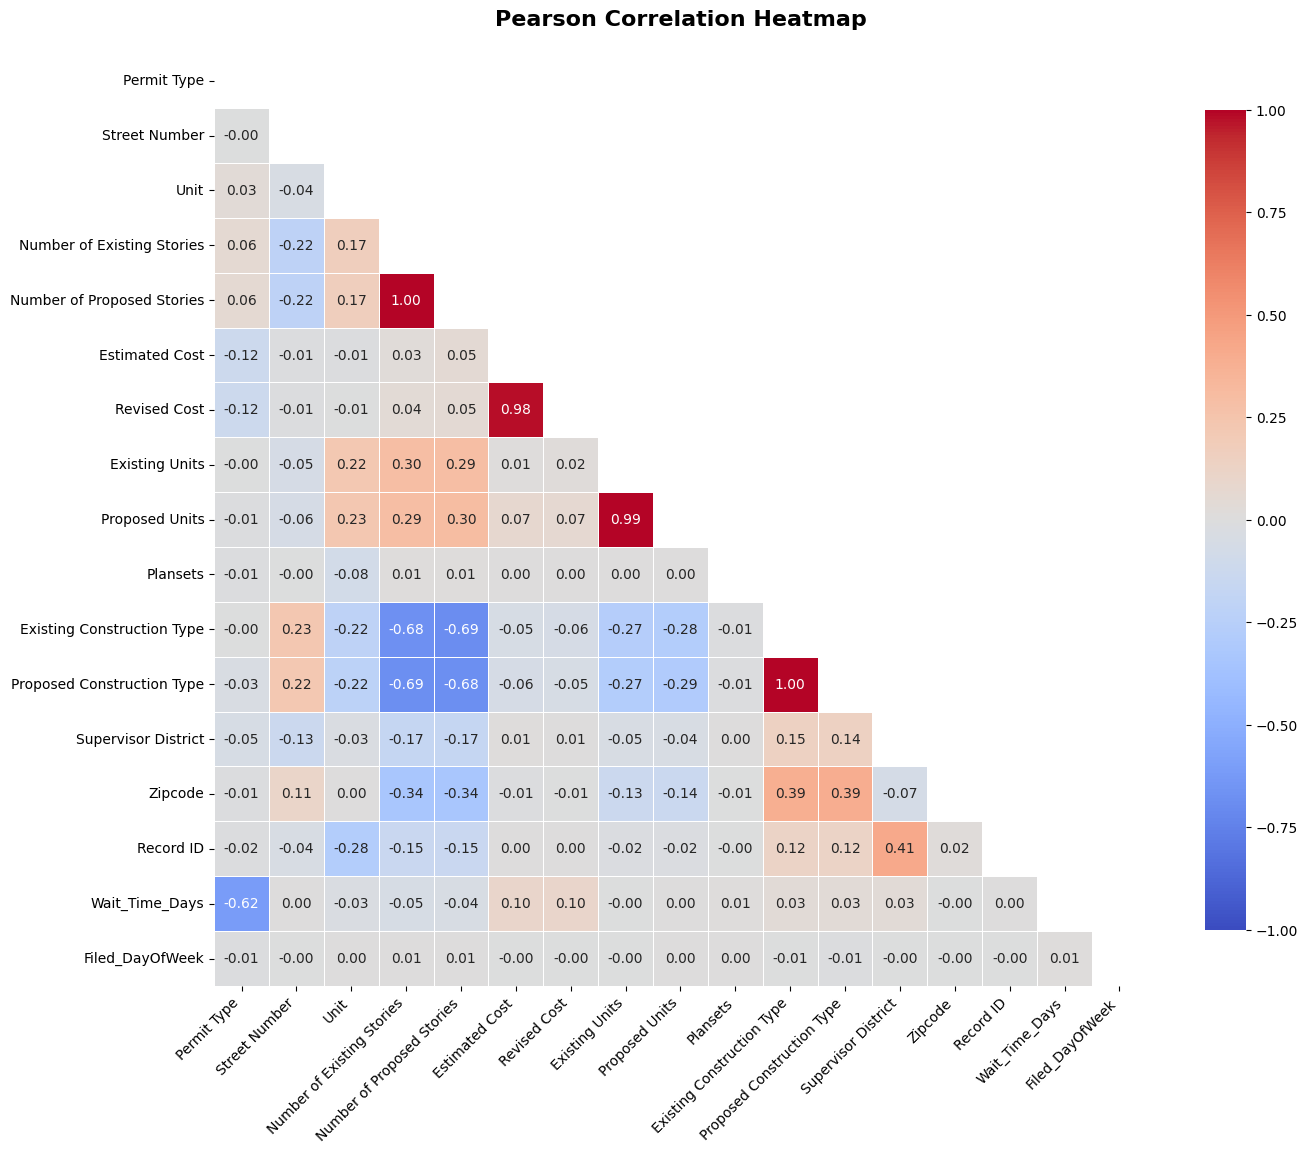


Method: Pearson
Status: Success
  - Tương quan MẠNH (|r| >= 0.7):
      + [Existing Construction Type] & [Proposed Construction Type]: r = 0.9990
      + [Number of Existing Stories] & [Number of Proposed Stories]: r = 0.9974
      + [Existing Units] & [Proposed Units]: r = 0.9941
      + [Estimated Cost] & [Revised Cost]: r = 0.9788
  - Tương quan CỰC YẾU (Top 5):
      + [Existing Units] & [Filed_DayOfWeek]: r = -0.0003
      + [Proposed Units] & [Filed_DayOfWeek]: r = 0.0006
      + [Estimated Cost] & [Filed_DayOfWeek]: r = -0.0012
      + [Record ID] & [Wait_Time_Days]: r = 0.0012
      + [Existing Units] & [Plansets]: r = 0.0012

   [INFO] Đang thực thi Correlation Analysis (Spearman)...


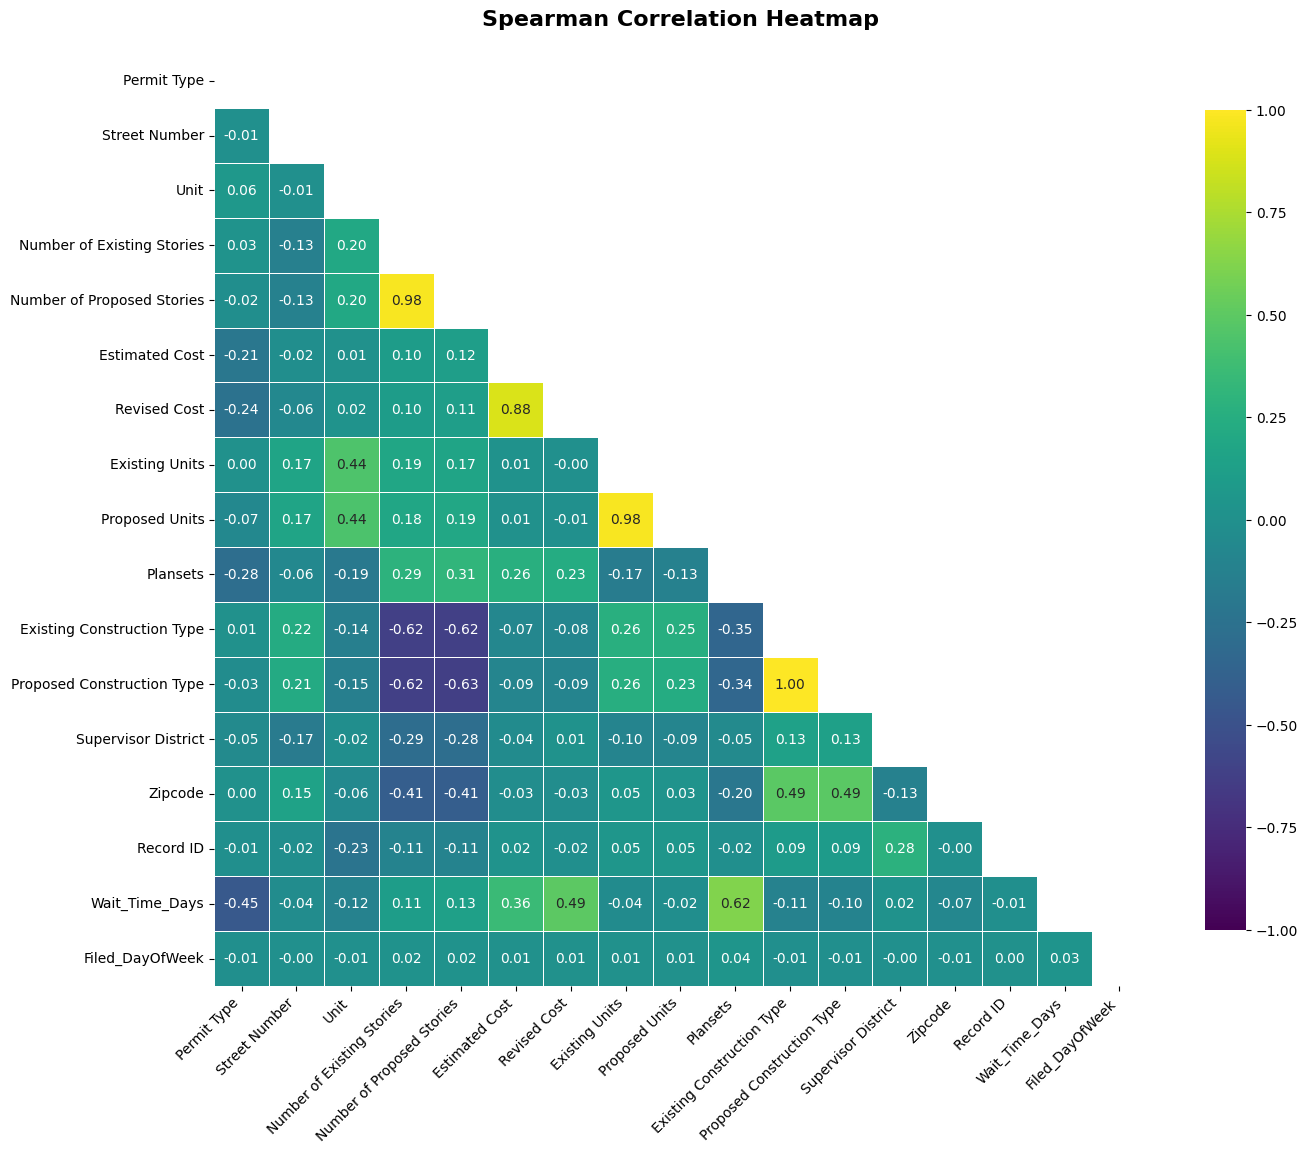


Method: Spearman
Status: Success
  - Tương quan MẠNH (|r| >= 0.7):
      + [Existing Construction Type] & [Proposed Construction Type]: r = 0.9988
      + [Number of Existing Stories] & [Number of Proposed Stories]: r = 0.9817
      + [Existing Units] & [Proposed Units]: r = 0.9814
      + [Estimated Cost] & [Revised Cost]: r = 0.8836
  - Tương quan CỰC YẾU (Top 5):
      + [Permit Type] & [Zipcode]: r = 0.0006
      + [Street Number] & [Filed_DayOfWeek]: r = -0.0023
      + [Supervisor District] & [Filed_DayOfWeek]: r = -0.0030
      + [Zipcode] & [Record ID]: r = -0.0032
      + [Revised Cost] & [Existing Units]: r = -0.0039


In [1]:
%matplotlib inline
import sys, os, warnings
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

if os.path.abspath('../src') not in sys.path:
    sys.path.append(os.path.abspath('../src'))

# ==============================================================================
# HACK BẺ KHÓA 'Agg' ĐỂ ÉP HIỂN THỊ ẢNH TRÊN NOTEBOOK
# ==============================================================================
import visualization.relationship as rel
rel.plt.show = lambda: display(rel.plt.gcf())

from table.analysis_correlation import CorrelationAnalysis
from config.settings import PATH_FOLDER_TABLE_RAW

csv_path = os.path.join(PATH_FOLDER_TABLE_RAW, "Building_Permits.csv")
print(f"[INFO] Đang nạp bộ dữ liệu từ: {csv_path} ...")
df = pd.read_csv(csv_path, low_memory=False)

df['Filed Date'] = pd.to_datetime(df['Filed Date'], errors='coerce')
df['Issued Date'] = pd.to_datetime(df['Issued Date'], errors='coerce')
df['Wait_Time_Days'] = (df['Issued Date'] - df['Filed Date']).dt.days
df['Filed_DayOfWeek'] = df['Filed Date'].dt.dayofweek

df_numeric = df.select_dtypes(include=['float64', 'int64', 'int32']).dropna(axis=1, how='all')

print("\n" + "="*50)
pearson_analyzer = CorrelationAnalysis(method='pearson', threshold=0.7)
pearson_analyzer.run(df_numeric)

print("\n" + "="*50)
spearman_analyzer = CorrelationAnalysis(method='spearman', threshold=0.7)
spearman_analyzer.run(df_numeric)

<a id="sec-6"></a>

# 5. Báo cáo kết quả: Phân tích tương quan

Dựa vào hai biểu đồ Heatmap hệ số tương quan Pearson và Spearman được trích xuất từ bộ dữ liệu, chúng ta có các nhận xét và kết luận như sau:

<a id="sec-6-1"></a>

## 5.1. Nhận xét trực quan biểu đồ

<a id="sec-6-1-1"></a>

### 5.1.1 Giá trị tương quan lớn nhất (Màu Đỏ trên Pearson / Vàng trên Spearman)
Đây là các cặp biến có hệ số tiệm cận mức hoàn hảo ($r \approx 0.98$ đến $1.00$). Chúng biểu hiện mối quan hệ đồng biến cực mạnh (X tăng thì Y tăng theo tỷ lệ tương đương).
* **Đại diện:** 
    * `Number of Existing Stories` & `Number of Proposed Stories` ($r = 1.00$ / $\rho = 0.98$)
    * `Existing Units` & `Proposed Units` ($r = 0.99$ / $\rho = 0.98$)
    * `Estimated Cost` & `Revised Cost` ($r = 0.98$ / $\rho = 0.88$)
    * `Existing Construction Type` & `Proposed Construction Type` ($r = 1.00$ / $\rho = 1.00$)
* **Ý nghĩa:** Nhóm dữ liệu này đang gặp vấn đề **đa cộng tuyến** nghiêm trọng. Thông tin trước và sau khi cấp phép gần như trùng lắp hoàn toàn. Để tối ưu mô hình học máy sau này, ta buộc phải loại bỏ một nửa số biến (Ví dụ: Chỉ giữ lại thuộc tính Proposed, bỏ Existing).

<a id="sec-6-1-2"></a>

### 5.1.2 Giá trị tương quan bé nhất (Màu Xanh đậm trên Pearson / Tím sậm trên Spearman)
Đây là các cặp biến có tương quan nghịch (X tăng thì Y giảm).
* **Đại diện:** * `Wait_Time_Days` & `Permit Type` có tương quan nghịch khá rõ ở cả hai biểu đồ (Pearson: $-0.62$, Spearman: $-0.45$).
    * Các biến cấu trúc (`Stories`, `Units`) có tương quan nghịch với `Construction Type` (khoảng $-0.62$ đến $-0.69$).

### 1.3 Cặp biến không tương quan (Màu Ghi nhạt / Xanh lục ngọc)
* **Đại diện:** Biến `Filed_DayOfWeek` (Ngày nộp hồ sơ) có hệ số tiệm cận $0.00$ đến $\pm0.04$ với tất cả các biến còn lại trong hệ thống.
* **Ý nghĩa:** Sự biến động của ngày nộp hồ sơ hoàn toàn độc lập, không chịu tác động và cũng không tác động đến bất kỳ yếu tố quy mô công trình hay thời gian chờ nào.

---

<a id="sec-6-2"></a>

## 5.2. Giải đáp 3 câu hỏi kinh doanh

<a id="sec-6-2-1"></a>

### Câu hỏi 1: Có thể dự đoán thời gian cấp phép (`Wait_Time_Days`) cho các loại giấy phép không? Yếu tố nào quan trọng hơn?
* **Kết luận:** Có thể dự đoán được. Tuy nhiên, mối quan hệ này không phải là đường thẳng tuyến tính mà là phi tuyến - Spearman.
* **Phân tích từ dữ liệu:** * Nếu nhìn vào bảng **Pearson**, ta thấy `Wait_Time_Days` dường như không liên quan đến chi phí (`Estimated Cost` chỉ là 0.10).
    * Nhưng khi nhìn sang bảng **Spearman** (chuyên bắt các quy luật phi tuyến), `Wait_Time_Days` có sự tương quan thuận rất tốt với:
        1.  **`Plansets` (Số lượng bản vẽ/hồ sơ):** $\rho = 0.62$ (Tương quan mạnh nhất).
        2.  **`Revised Cost` (Chi phí sau điều chỉnh):** $\rho = 0.49$.
        3.  **`Estimated Cost` (Chi phí dự toán):** $\rho = 0.36$.
    * Đồng thời, nó tương quan nghịch với **`Permit Type`** ($-0.45$).
* **Insight:** Thời gian chờ cấp phép không tăng đều theo từng đồng chi phí, mà nó **phụ thuộc nặng nề vào độ phức tạp của hồ sơ (`Plansets`) và loại giấy phép (`Permit Type`)**. Hồ sơ càng nhiều bản vẽ kỹ thuật, quy mô chi phí càng lớn, cơ quan chức năng càng mất nhiều thời gian để thẩm định phi tuyến tính (ví dụ: dự án 10 tỷ xử lý mất 1 tháng, nhưng dự án 100 tỷ có thể mất tới 6 tháng do phải qua nhiều ban bệ phê duyệt chứ không tăng gấp 10 lần một cách cơ học).

<a id="sec-6-2-2"></a>

### Câu hỏi 2: Dựa trên dữ liệu, gợi ý ngày nào trong tuần là ngày tốt nhất để đến Sở Kiểm tra Xây dựng?
* **Kết luận:** Đứng ở góc độ **rút ngắn thời gian chờ cấp phép**, không có ngày nào là tốt nhất.
* **Phân tích từ dữ liệu:** Biến `Filed_DayOfWeek` có hệ số tương quan tiệm cận bằng **$0.00$** với cột `Wait_Time_Days` trên cả 2 Heatmap. Nghĩa là việc nếu nộp hồ sơ vào Thứ 2 hay Thứ 6 không hề làm thay đổi tốc độ thẩm định của cơ quan nhà nước.
* **Insight:** Vì ngày trong tuần hoàn toàn độc lập với hệ thống cấp phép, lời khuyên thực tế là người dân nên đến vào **giữa tuần (Thứ 3, Thứ 4)** để nộp hồ sơ. Điều này giúp tránh được tâm lý đám đông thường đổ xô đi nộp vào ngày đầu tuần (Thứ 2) hoặc chạy deadline vào ngày cuối tuần (Thứ 6), qua đó tiết kiệm được *thời gian xếp hàng chờ đợi trực tiếp tại quầy*, dù *thời gian cơ quan xử lý hồ sơ* là không thay đổi.

<a id="sec-6-2-3"></a>

### Câu hỏi 3: Đưa ra kết luận gì về sự phát triển của thành phố San Francisco?
* **Kết luận:** Thành phố đang phát triển theo định hướng **bảo tồn, cải tạo và nâng cấp** thay vì đập bỏ xây mới hoàn toàn.
* **Phân tích từ dữ liệu:** Heatmap cho thấy một mảng màu đỏ/vàng rực ($0.98 - 1.00$) xuất hiện khi đối chiếu các chỉ số `Existing` (Hiện có) và `Proposed` (Đề xuất) như Số tầng, Số căn hộ, Loại hình xây dựng.
* **Insight:** Việc số liệu kiến trúc trước và sau khi xin giấy phép gần như đồng nhất ($r \approx 1.0$) phản ánh đặc thù của một thành phố lớn, lâu đời và đã cạn kiệt quỹ đất trống. Hầu hết các giấy phép xây dựng được cấp ra là dành cho các hoạt động sửa chữa nội bộ, gia cố cấu trúc, hoặc chuyển đổi công năng bên trong tòa nhà cũ, chứ không phải để đập đi xây lại nhằm thay đổi toàn diện quy mô (ví dụ: biến nhà 2 tầng thành chung cư 20 tầng).